# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import xml.etree.ElementTree as ET

# mujoco
if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# opensim
sys.path.append("/home/seojin/miniforge3/envs/myoconverter/lib/python3.10/site-packages")
import opensim

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from sj_opensim import extract_muscle_names, extract_muscle_params
from biomechanics_util import extract_mujoco_muscle_gain_params, extract_mujoco_muscle_bias_params

# Opensim

In [3]:
osim_dir_path = "/mnt/sdb2/DeepProprioception/OpenSim"
osim_file_path = os.path.join(osim_dir_path, "MOBL_ARMS_41.osim")
osim_muscle_params = extract_muscle_params(osim_file_path)

# Mujoco

In [4]:
converted_model_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_fixed_41/temp_cvt3.xml"
converted_muscle_gain_params = extract_mujoco_muscle_gain_params(converted_model_path)
converted_muscle_bias_params = extract_mujoco_muscle_bias_params(converted_model_path)

muscle_names = converted_muscle_gain_params.columns
param_names = list(converted_muscle_gain_params.index)

# Myoarm

In [5]:
myoarm_model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"
myoarm_muscle_gain_params = extract_mujoco_muscle_gain_params(myoarm_model_path)
myoarm_muscle_bias_params = extract_mujoco_muscle_bias_params(myoarm_model_path)

apl_i = list(myoarm_muscle_gain_params.columns).index("APL")
myoarm_muscle_gain_params = myoarm_muscle_gain_params.iloc[:, :apl_i + 1]
myoarm_muscle_gain_params.columns = muscle_names

myoarm_muscle_bias_params = myoarm_muscle_bias_params.iloc[:, :apl_i + 1]
myoarm_muscle_bias_params.columns = muscle_names

In [6]:
def compare_plot(converted_gain_params, myoarm_gain_params,
                 converted_bias_params, myoarm_bias_params, 
                 param_name):
    fig, axis = plt.subplots(1)
    fig.set_figwidth(10)
    axis.plot(converted_gain_params.loc[param_name], label = "converted_gain")
    axis.plot(myoarm_gain_params.loc[param_name], label = "myoarm_gain")
    axis.plot(converted_bias_params.loc[param_name], label = "converted_bias")
    axis.plot(myoarm_bias_params.loc[param_name], label = "myoarm_bias")
    axis.set_xticks(np.arange(len(muscle_names)), muscle_names, rotation = 90)
    axis.set_title(param_name)
    axis.legend()

# Musculo tendon length

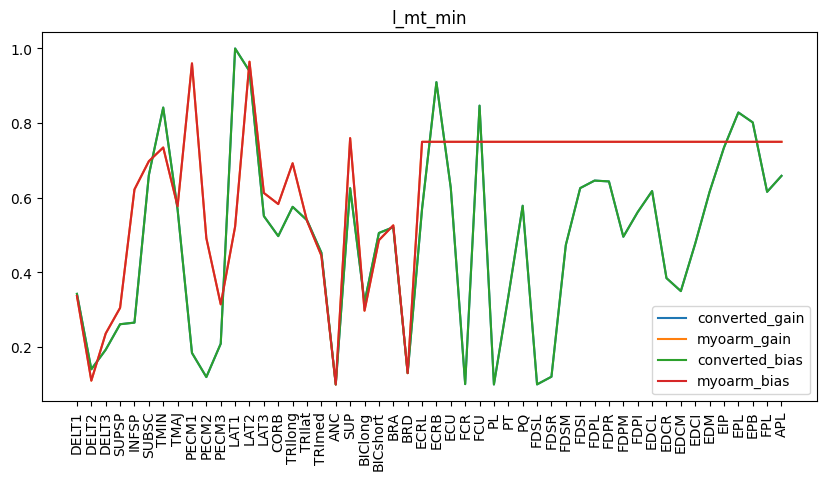

In [7]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "l_mt_min")

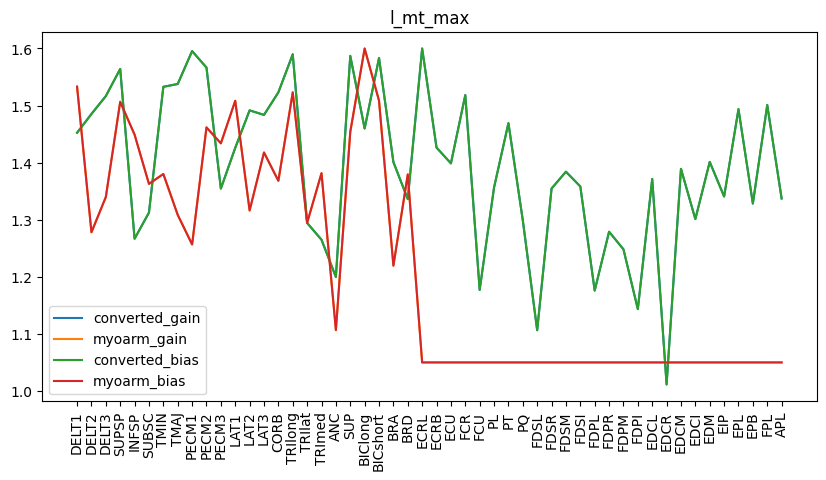

In [8]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "l_mt_max")

# Maximum force

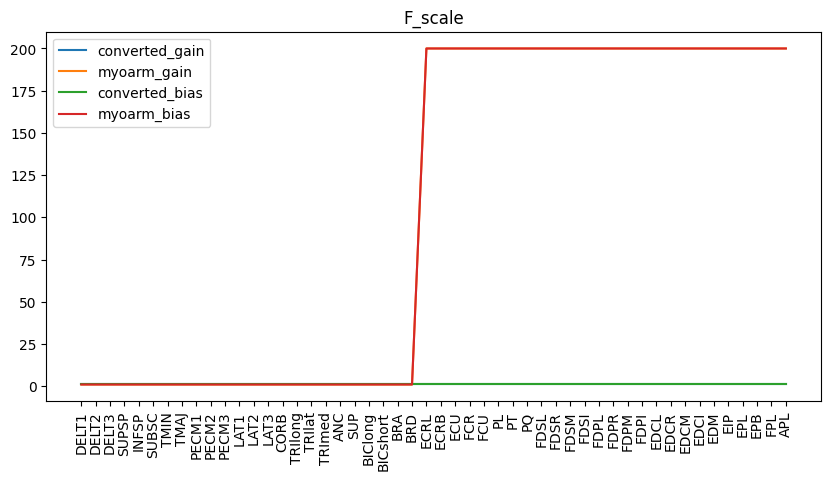

In [9]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "F_scale")

# Muscle length

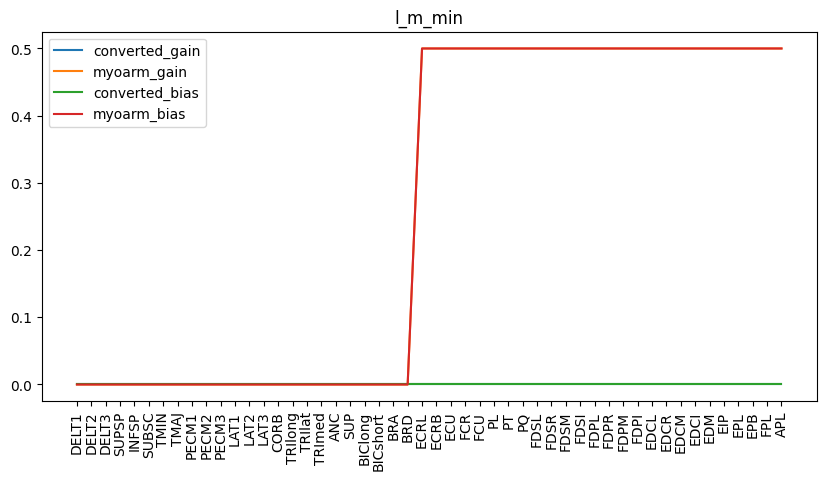

In [10]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "l_m_min")

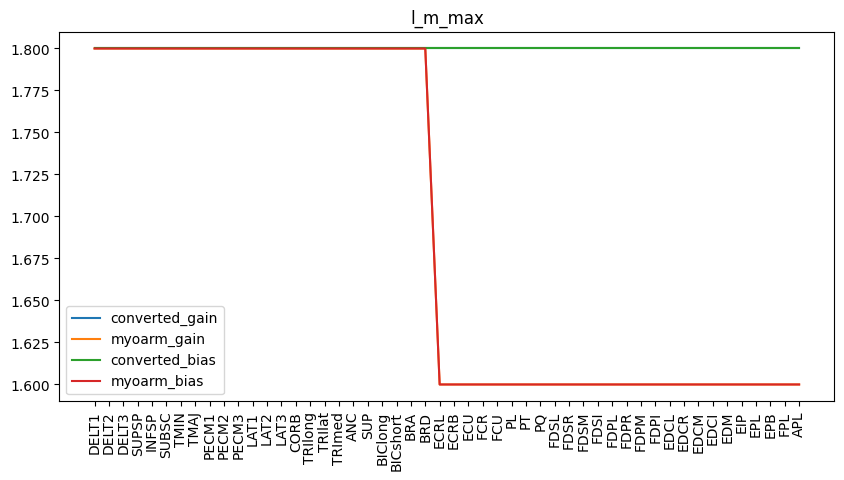

In [11]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "l_m_max")

# Muscle velocity

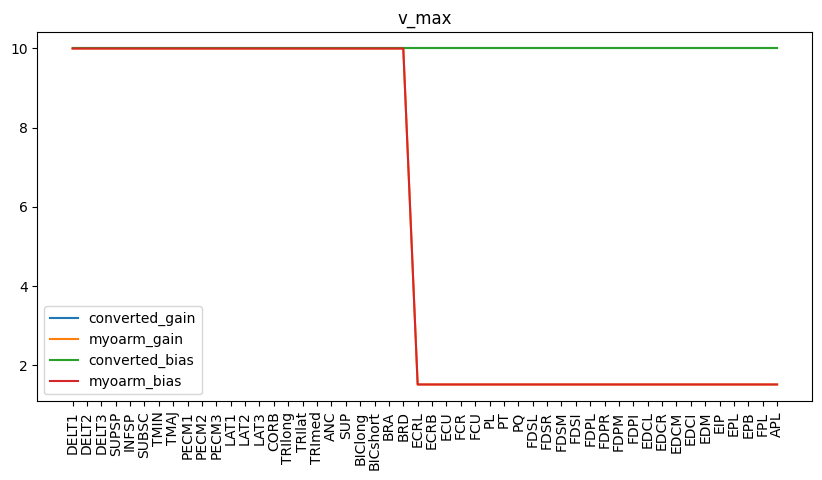

In [12]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "v_max")

# fp_max

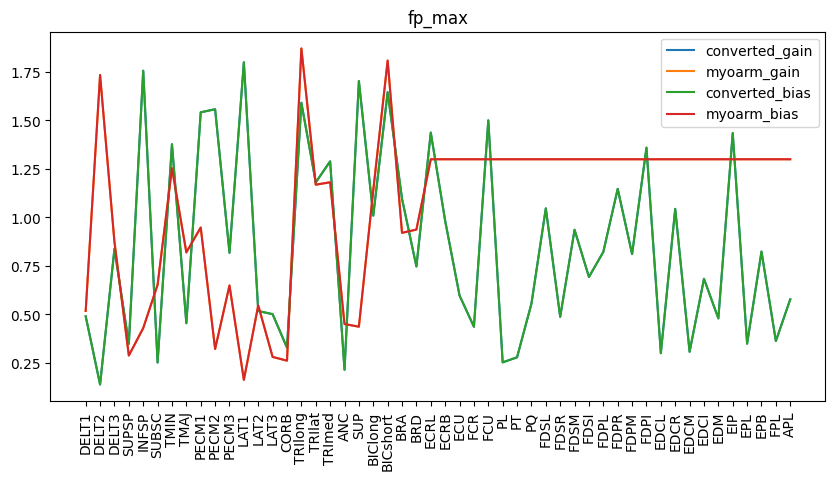

In [13]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "fp_max")

# fv_max

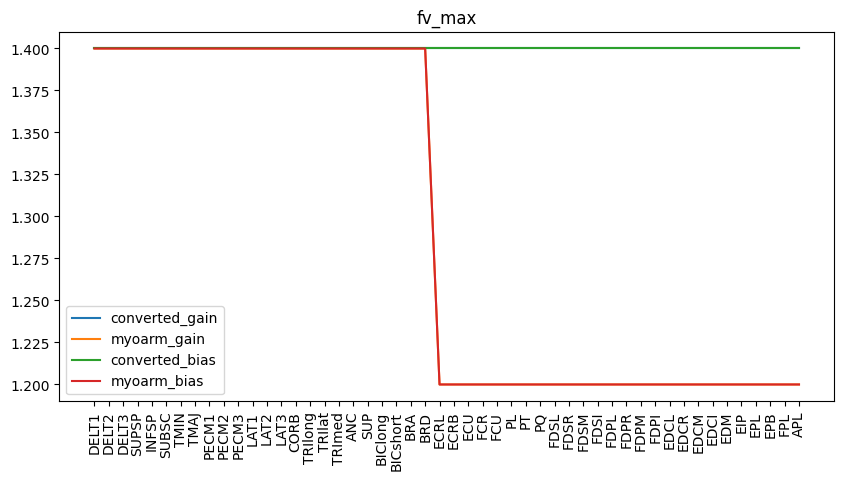

In [14]:
compare_plot(converted_muscle_gain_params, 
             myoarm_muscle_gain_params, 
             converted_muscle_bias_params,
             myoarm_muscle_bias_params,
             "fv_max")

# Change

In [15]:
# os.system(f"cp {converted_model_path} {converted_model_path}.original")
scaled_muscles = list(myoarm_muscle_gain_params.loc[:, list(myoarm_muscle_gain_params.loc["F_scale"] == 200)].columns)

In [21]:
l_mt_min_i = param_names.index("l_mt_min")
l_mt_max_i = param_names.index("l_mt_max")
f_scale_i = param_names.index("F_scale")
l_m_min_i = param_names.index("l_m_min")
l_m_max_i = param_names.index("l_m_max")
v_max_i = param_names.index("v_max")
fp_max_i = param_names.index("fp_max")
fv_max_i = param_names.index("fv_max")

In [26]:
tree = ET.parse(converted_model_path)
root = tree.getroot()

for muscle_name in scaled_muscles:
    for actuator in root.findall(".//actuator/*"):
        if actuator.get("name") == muscle_name:
            gainprm = actuator.get("gainprm")
            biasprm = actuator.get("biasprm")

            if gainprm and biasprm:
                gainprm_val = gainprm.split(" ")
                gainprm_val[f_scale_i] = str(myoarm_muscle_gain_params.loc["F_scale", muscle_name])
                gainprm_val[v_max_i] = str(myoarm_muscle_gain_params.loc["v_max", muscle_name])
                gainprm_val[fp_max_i] = str(myoarm_muscle_gain_params.loc["fp_max", muscle_name])
                gainprm_val[fv_max_i] = str(myoarm_muscle_gain_params.loc["fv_max", muscle_name])
                
                gainprm_val[l_mt_min_i] = str(myoarm_muscle_gain_params.loc["l_mt_min", muscle_name])
                gainprm_val[l_mt_max_i] = str(myoarm_muscle_gain_params.loc["l_mt_max", muscle_name])
                gainprm_val[l_m_min_i] = str(myoarm_muscle_gain_params.loc["l_m_min", muscle_name])
                gainprm_val[l_m_max_i] = str(myoarm_muscle_gain_params.loc["l_m_max", muscle_name])
                
                actuator.set("gainprm", " ".join(gainprm_val))
                
                
                biasprm_val = biasprm.split(" ")
                biasprm_val[f_scale_i] = str(myoarm_muscle_bias_params.loc["F_scale", muscle_name])
                biasprm_val[v_max_i] = str(myoarm_muscle_bias_params.loc["v_max", muscle_name])
                biasprm_val[fp_max_i] = str(myoarm_muscle_bias_params.loc["fp_max", muscle_name])
                biasprm_val[fv_max_i] = str(myoarm_muscle_bias_params.loc["fv_max", muscle_name])
                
                biasprm_val[l_mt_min_i] = str(myoarm_muscle_bias_params.loc["l_mt_min", muscle_name])
                biasprm_val[l_mt_max_i] = str(myoarm_muscle_bias_params.loc["l_mt_max", muscle_name])
                biasprm_val[l_m_min_i] = str(myoarm_muscle_bias_params.loc["l_m_min", muscle_name])
                biasprm_val[l_m_max_i] = str(myoarm_muscle_bias_params.loc["l_m_max", muscle_name])
                
                actuator.set("biasprm", " ".join(biasprm_val))
            break
            
tree.write(converted_model_path, encoding='utf-8', xml_declaration=True)
print(f"saved: {converted_model_path}")

saved: /mnt/ext1/seojin/temp/MOBL_ARMS_41_bounded/temp_cvt3.xml


In [19]:
def get_mean_lengthrange(root, muscle_name):
    tree = ET.parse(converted_model_path)
    root = tree.getroot()
    for actuator in root.findall(".//actuator/*"):
        if actuator.get("name") == muscle_name:
            lr_str = actuator.get("lengthrange")
            if lr_str:
                lr_vals = [float(x) for x in lr_str.split()]
                return sum(lr_vals) / len(lr_vals) # (min + max) / 2
    return None

In [28]:
get_mean_lengthrange(converted_model_path, "DELT1")

0.1814115

In [29]:
myoarm_muscle_gain_params.loc['l_mt_min', "DELT1"] * 0.18

0.06067259999999999

In [30]:
myoarm_muscle_gain_params.loc['l_mt_min', "DELT1"]

0.33707

In [ ]:
import xml.etree.ElementTree as ET

# 1. 두 모델의 XML 트리 파싱
converted_tree = ET.parse(converted_model_path)
converted_root = converted_tree.getroot()

myoarm_tree = ET.parse(myoarm_model_path)
myoarm_root = myoarm_tree.getroot()

# (도우미 함수) XML에서 특정 근육의 lengthrange 평균값을 가져옵니다.
def get_mean_lengthrange(root, muscle_name):
    for actuator in root.findall(".//actuator/*"):
        if actuator.get("name") == muscle_name:
            lr_str = actuator.get("lengthrange")
            if lr_str:
                lr_vals = [float(x) for x in lr_str.split()]
                return sum(lr_vals) / len(lr_vals) # (min + max) / 2
    return None

# 2. 파라미터 매핑 및 스케일링 적용
for muscle_name in scaled_muscles:
    # 2-A. 스케일 비율(Scale Ratio) 계산
    conv_len = get_mean_lengthrange(converted_root, muscle_name)
    orig_len = get_mean_lengthrange(myoarm_root, muscle_name)
    
    if conv_len is None or orig_len is None:
        print(f"Warning: {muscle_name}의 lengthrange를 찾을 수 없습니다. 건너뜁니다.")
        continue
        
    scale_ratio = conv_len / orig_len
    
    # 2-B. Converted 모델에서 액추에이터 업데이트
    for actuator in converted_root.findall(".//actuator/*"):
        if actuator.get("name") == muscle_name:
            gainprm = actuator.get("gainprm")
            biasprm = actuator.get("biasprm")
            
            if gainprm and biasprm:
                gainprm_val = gainprm.split(" ")
                biasprm_val = biasprm.split(" ")
                
                # ==========================================
                # [수정 1] 길이(Length) 변수는 스케일 비율을 곱해서 할당
                # ==========================================
                # float()로 변환 후 ratio를 곱하고, 다시 소수점 6자리 문자열로 포맷팅합니다.
                
                # Gain params 길이 스케일링
                gainprm_val[l_mt_min_i] = f"{float(myoarm_muscle_gain_params.loc['l_mt_min', muscle_name]) * scale_ratio:.6g}"
                gainprm_val[l_mt_max_i] = f"{float(myoarm_muscle_gain_params.loc['l_mt_max', muscle_name]) * scale_ratio:.6g}"
                gainprm_val[l_m_min_i]  = f"{float(myoarm_muscle_gain_params.loc['l_m_min', muscle_name]) * scale_ratio:.6g}"
                gainprm_val[l_m_max_i]  = f"{float(myoarm_muscle_gain_params.loc['l_m_max', muscle_name]) * scale_ratio:.6g}"
                
                # Bias params 길이 스케일링
                biasprm_val[l_mt_min_i] = f"{float(myoarm_muscle_bias_params.loc['l_mt_min', muscle_name]) * scale_ratio:.6g}"
                biasprm_val[l_mt_max_i] = f"{float(myoarm_muscle_bias_params.loc['l_mt_max', muscle_name]) * scale_ratio:.6g}"
                biasprm_val[l_m_min_i]  = f"{float(myoarm_muscle_bias_params.loc['l_m_min', muscle_name]) * scale_ratio:.6g}"
                biasprm_val[l_m_max_i]  = f"{float(myoarm_muscle_bias_params.loc['l_m_max', muscle_name]) * scale_ratio:.6g}"

                # ==========================================
                # [수정 2] 힘/속도(Force/Velocity) 변수는 원본 1:1 복사
                # ==========================================
                gainprm_val[f_scale_i] = str(myoarm_muscle_gain_params.loc["F_scale", muscle_name])
                gainprm_val[v_max_i]   = str(myoarm_muscle_gain_params.loc["v_max", muscle_name])
                gainprm_val[fp_max_i]  = str(myoarm_muscle_gain_params.loc["fp_max", muscle_name])
                gainprm_val[fv_max_i]  = str(myoarm_muscle_gain_params.loc["fv_max", muscle_name])
                
                biasprm_val[f_scale_i] = str(myoarm_muscle_bias_params.loc["F_scale", muscle_name])
                biasprm_val[v_max_i]   = str(myoarm_muscle_bias_params.loc["v_max", muscle_name])
                biasprm_val[fp_max_i]  = str(myoarm_muscle_bias_params.loc["fp_max", muscle_name])
                biasprm_val[fv_max_i]  = str(myoarm_muscle_bias_params.loc["fv_max", muscle_name])
                
                # XML 속성에 다시 주입
                actuator.set("gainprm", " ".join(gainprm_val))
                actuator.set("biasprm", " ".join(biasprm_val))
            
            break # 해당 근육을 찾았으므로 안쪽 루프 탈출

# 3. 변경된 내용 파일로 저장
converted_tree.write(converted_model_path, encoding='utf-8', xml_declaration=True)
print(f"saved: {converted_model_path}")